In [1]:
import pandas as pd
import numpy
import networkx as nx
from tqdm.notebook import tqdm
import seaborn as sns
import matplotlib.pyplot as plt


import umap

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

df = pd.read_csv('csv/flat-training.csv')

X_train, X_test = train_test_split(df, train_size=0.8)

# X_train, X_val = train_test_split(X_tv, train_size=0.5)

original_index_values = X_train.reset_index()['index']

#df_o = df.select_dtypes(include='object')

#df_no = df.select_dtypes(exclude='object')

X_train_o = X_train.select_dtypes(include='object').fillna('iamna')

X_train_dummies = pd.get_dummies(X_train)

X_train_no = X_train.select_dtypes(exclude='object').fillna(0)

#X_val_no = X_val.select_dtypes(exclude='object').fillna(0)

# scaler_no = StandardScaler()

# X_train_no_scaled = pd.DataFrame(scaler_no.fit_transform(X_train_no))



scaler_no = MinMaxScaler()

scaler_no.fit(X_train_dummies)

X_train_scaled=pd.DataFrame(scaler_no.transform(X_train_dummies))




2025-06-02 16:07:12.965095: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-06-02 16:07:12.966514: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-02 16:07:12.995419: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-02 16:07:12.996061: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-06-02 16:07:13.604458: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT

In [251]:
import scipy.stats as stats
from sklearn import preprocessing

X_train_cat = X_train.copy()

le = preprocessing.LabelEncoder()
for i,col in enumerate(X_train_o.columns.tolist()):
    X_train_cat[col] = le.fit_transform(X_train_cat[col].fillna('iamna'))

for i, col in enumerate(X_train_cat.select_dtypes(exclude='object').columns.tolist()):
    X_train_cat[col] = X_train_cat[col].fillna(0)

col_one = []
col_two = []
corr_list = []
abs_corr_list = []
for i,col_1 in enumerate(X_train_cat.columns.tolist()):
    for j, col_2 in enumerate(X_train_cat.columns.tolist()):
        if col_1!=col_2:
            col_one.append(col_1)
            col_two.append(col_2)
            corr_list.append(stats.pointbiserialr(X_train_cat[col_1], X_train_cat[col_2])[0])
            abs_corr_list.append(abs(stats.pointbiserialr(X_train_cat[col_1], X_train_cat[col_2])[0]))


col_dict = {
    'col1': col_one,
    'col2': col_two,
    'corr': corr_list,
    'abs_corr': abs_corr_list
}

corr_df = pd.DataFrame.from_dict(col_dict)
        


In [252]:
corr_df[corr_df['col1'] == 'hedgehog']

,col1,col2,corr,abs_corr
553,hedgehog,dog,0.001879,0.001879
554,hedgehog,cat,-0.008628,0.008628
555,hedgehog,rabbit,-0.014778,0.014778
556,hedgehog,deer,-0.051242,0.051242
557,hedgehog,panda,-0.001595,0.001595
...,...,...,...,...
627,hedgehog,storybook,0.000839,0.000839
628,hedgehog,candle,-0.421693,0.421693
629,hedgehog,clover,0.006710,0.006710
630,hedgehog,bubble,-0.015001,0.015001


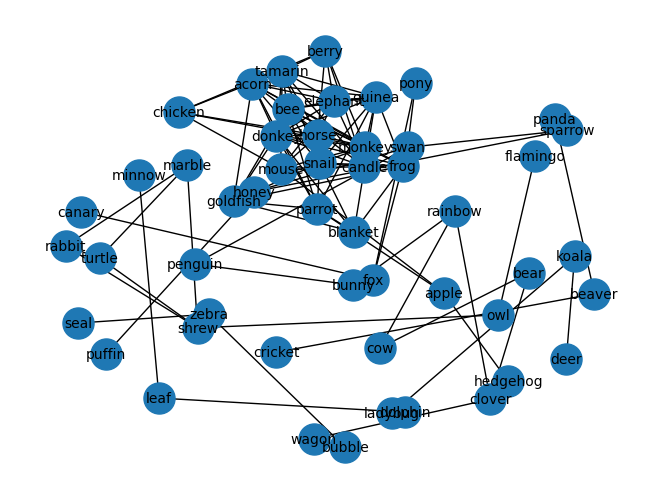

In [253]:
R = 0.45
S = 0.8
df_R = corr_df[(corr_df['abs_corr'] > R)&(corr_df['abs_corr']<S)]

G=nx.from_pandas_edgelist(df_R, 'col1', 'col2', edge_attr='corr')

pos = nx.spring_layout(G, k=1, scale=5.0)  # increase `k` or `scale` for more spacing

# Draw the graph using the custom positions
nx.draw(G, pos, with_labels=True, node_size=500, font_size=10)

plt.show()

In [267]:
# Get connected components
components = list(nx.connected_components(G))

# Each component is a set of node names
component_list = []
for i, component in enumerate(components):
    print(f"Component {i+1}: {component}")
    component_list.append(list(component))

components_ = sorted(components, key=len, reverse=True)

component_list_core = []
for comp in components_:
    if len(comp) > 3:
        subgraph = G.subgraph(comp)
    
    # Filter nodes with degree > 1
        filtered_nodes = [n for n in subgraph.nodes if subgraph.degree[n] > 1]

    # Create the subgraph of only those nodes
        filtered_subgraph = subgraph.subgraph(filtered_nodes)

        filtered_nodes_two = [n for n in filtered_subgraph.nodes if filtered_subgraph.degree[n]>1]

        component_list_core.append(filtered_nodes)
    if len(comp) <= 3:
        component_list_core.append(list(comp))

flat_list = [item for sublist in component_list for item in sublist]

singles = [x for x in X_train.columns.tolist() if x not in flat_list]

single_lists_one = [[x] for x in singles]


Component 1: {'otter', 'whistle', 'flamingo', 'chipmunk', 'cub', 'bat', 'canary', 'wagon', 'puffin', 'hedgehog', 'wallaby', 'loon', 'puddle', 'llama', 'duck', 'goat', 'wombat', 'mole'}
Component 2: {'pumpkin', 'storybook'}


In [268]:
single_lists_one

[['dog'],
 ['cat'],
 ['rabbit'],
 ['deer'],
 ['panda'],
 ['koala'],
 ['squirrel'],
 ['dolphin'],
 ['penguin'],
 ['turtle'],
 ['elephant'],
 ['giraffe'],
 ['lamb'],
 ['cow'],
 ['horse'],
 ['donkey'],
 ['pony'],
 ['mouse'],
 ['hamster'],
 ['guinea'],
 ['chicken'],
 ['sparrow'],
 ['parrot'],
 ['finch'],
 ['bee'],
 ['butterfly'],
 ['ladybug'],
 ['snail'],
 ['frog'],
 ['cricket'],
 ['tamarin'],
 ['zebra'],
 ['peacock'],
 ['fox'],
 ['beaver'],
 ['monkey'],
 ['seal'],
 ['robin'],
 ['swan'],
 ['goldfish'],
 ['minnow'],
 ['shrew'],
 ['owl'],
 ['bunny'],
 ['bear'],
 ['acorn'],
 ['leaf'],
 ['cloud'],
 ['rainbow'],
 ['berry'],
 ['apple'],
 ['honey'],
 ['teddy'],
 ['blanket'],
 ['button'],
 ['marble'],
 ['candle'],
 ['clover'],
 ['bubble'],
 ['cookie']]

In [269]:
X_train_singles_cat = X_train[singles]
object_columns = X_train_singles_cat.select_dtypes(include='object').columns.tolist()

le = preprocessing.LabelEncoder()
for i,col in enumerate(object_columns):
    X_train_singles_cat[col] = le.fit_transform(X_train_singles_cat[col])

for i, col in enumerate(X_train_singles_cat.select_dtypes(exclude='object').columns.tolist()):
    X_train_singles_cat[col] = X_train_singles_cat[col].fillna(0)

col_one = []
col_two = []
corr_list = []
abs_corr_list = []
for i,col_1 in enumerate(X_train_singles_cat.columns.tolist()):
    for j, col_2 in enumerate(X_train_singles_cat.columns.tolist()):
        if col_1!=col_2:
            col_one.append(col_1)
            col_two.append(col_2)
            corr_list.append(stats.pointbiserialr(X_train_singles_cat[col_1], X_train_singles_cat[col_2])[0])
            abs_corr_list.append(abs(stats.pointbiserialr(X_train_singles_cat[col_1], X_train_singles_cat[col_2])[0]))

col_dict = {
    'col1': col_one,
    'col2': col_two,
    'corr': corr_list,
    'abs_corr': abs_corr_list
}

corr_df_singles = pd.DataFrame.from_dict(col_dict)

/tmp/ipykernel_192633/2970120257.py:6: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipykernel_192633/2970120257.py:6: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipykernel_192633/2970120257.py:6: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipykerne

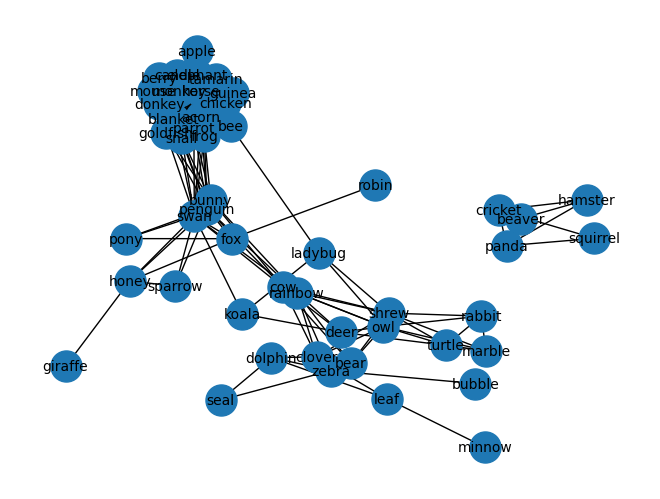

In [277]:
R = 0.2
S = 1
df_R = corr_df_singles[(corr_df_singles['abs_corr'] > R)&(corr_df_singles['abs_corr']<=S)]

G=nx.from_pandas_edgelist(df_R, 'col1', 'col2', edge_attr='corr')

pos = nx.spring_layout(G, k=0.5, scale=2.0)  # increase `k` or `scale` for more spacing

# Draw the graph using the custom positions
nx.draw(G, pos, with_labels=True, node_size=500, font_size=10)

plt.show()

In [278]:
# Get connected components
components = list(nx.connected_components(G))

# Each component is a set of node names
component_list_two = []
for i, component in enumerate(components):
    print(f"Component {i+1}: {component}")
    component_list_two.append(list(component))

components_ = sorted(components, key=len, reverse=True)

component_list_two_core = []
for comp in components_:
    if len(comp) > 3:
        subgraph = G.subgraph(comp)
    
    # Filter nodes with degree > 1
        filtered_nodes = [n for n in subgraph.nodes if subgraph.degree[n] > 1]

    # Create the subgraph of only those nodes
        filtered_subgraph = subgraph.subgraph(filtered_nodes)

        filtered_nodes_two = [n for n in filtered_subgraph.nodes if filtered_subgraph.degree[n]>1]

        component_list_two_core.append(filtered_nodes)
    if len(comp) <= 3:
        component_list_two_core.append(list(comp))


flat_list_two = [item for sublist in component_list_two_core for item in sublist]

singles = [x for x in X_train_singles_cat.columns.tolist() if x not in flat_list_two]

single_lists = [[x] for x in singles]

Component 1: {'monkey', 'cow', 'acorn', 'chicken', 'blanket', 'bear', 'snail', 'koala', 'berry', 'honey', 'bubble', 'tamarin', 'candle', 'seal', 'ladybug', 'shrew', 'deer', 'guinea', 'marble', 'dolphin', 'sparrow', 'goldfish', 'zebra', 'minnow', 'penguin', 'horse', 'leaf', 'owl', 'pony', 'apple', 'rainbow', 'fox', 'robin', 'turtle', 'mouse', 'clover', 'frog', 'donkey', 'parrot', 'giraffe', 'elephant', 'bee', 'swan', 'rabbit', 'bunny'}
Component 2: {'cricket', 'squirrel', 'panda', 'beaver', 'hamster'}


In [279]:
single_lists

[['dog'],
 ['cat'],
 ['giraffe'],
 ['lamb'],
 ['finch'],
 ['butterfly'],
 ['peacock'],
 ['robin'],
 ['minnow'],
 ['cloud'],
 ['teddy'],
 ['button'],
 ['bubble'],
 ['cookie']]

In [280]:
component_list_col = []
entry_col = []
corr_col = []
component_list_updated = []
for entry in singles:
    for component in component_list+component_list_two_core:
        if entry not in component:
            col_list = component + [entry]
            entry_col.append(entry)
            component_list_col.append(component)
            corr_col.append(X_train_cat[col_list].corr()[entry].drop(entry).max())
            component_list_updated.append(col_list)

col_dict = {
    'entry': entry_col,
    'component': component_list_col,
    'correlation': corr_col,
    'updated_component': component_list_updated
}

corr_df_matching = pd.DataFrame().from_dict(col_dict)
corr_df_matching['component_length'] = corr_df_matching.component.apply(len)
corr_df_matching['abs_correlation'] = abs(corr_df_matching.correlation)

remaining_columns = corr_df_matching.sort_values(['abs_correlation', 'component_length'], ascending=False).drop_duplicates('entry')
remaining_columns = remaining_columns[remaining_columns.abs_correlation > 0.04]

In [281]:
remaining_columns

,entry,component,correlation,updated_component,component_length,abs_correlation
30,robin,"[rabbit, turtle, shrew, owl, marble, deer, koa...",0.296813,"[rabbit, turtle, shrew, owl, marble, deer, koa...",41,0.296813
50,bubble,"[rabbit, turtle, shrew, owl, marble, deer, koa...",0.185616,"[rabbit, turtle, shrew, owl, marble, deer, koa...",41,0.185616
34,minnow,"[rabbit, turtle, shrew, owl, marble, deer, koa...",0.175544,"[rabbit, turtle, shrew, owl, marble, deer, koa...",41,0.175544
14,lamb,"[rabbit, turtle, shrew, owl, marble, deer, koa...",0.174162,"[rabbit, turtle, shrew, owl, marble, deer, koa...",41,0.174162
10,giraffe,"[rabbit, turtle, shrew, owl, marble, deer, koa...",0.141585,"[rabbit, turtle, shrew, owl, marble, deer, koa...",41,0.141585
54,cookie,"[rabbit, turtle, shrew, owl, marble, deer, koa...",0.106051,"[rabbit, turtle, shrew, owl, marble, deer, koa...",41,0.106051
4,cat,"[otter, whistle, flamingo, chipmunk, cub, bat,...",0.087096,"[otter, whistle, flamingo, chipmunk, cub, bat,...",18,0.087096
16,finch,"[otter, whistle, flamingo, chipmunk, cub, bat,...",0.050077,"[otter, whistle, flamingo, chipmunk, cub, bat,...",18,0.050077
38,cloud,"[rabbit, turtle, shrew, owl, marble, deer, koa...",0.040321,"[rabbit, turtle, shrew, owl, marble, deer, koa...",41,0.040321


In [282]:
remaining_columns['component_tuple'] = remaining_columns['component'].apply(tuple)

# Group by the component tuple and aggregate entries
df_grouped = (
    remaining_columns
    .groupby('component_tuple')['entry']
    .apply(list)
    .reset_index()
    .rename(columns={'entry': 'entries'})
)

# Optionally convert the component_tuple back to list
df_grouped['component'] = df_grouped['component_tuple'].apply(list)

# Drop the tuple column if not needed
df_grouped = df_grouped.drop(columns='component_tuple')

In [283]:
# Step 1: Prepare your base data
entry_set = set(remaining_columns['entry'])  # fast lookup

# Step 2: Remove single-entry lists matching any entry
filtered_components = [
    comp for comp in component_list+component_list_two_core+single_lists
    if not (len(comp) == 1 and comp[0] in entry_set)
]

# Step 3: Copy the list to mutate safely
updated_components = [list(comp) for comp in filtered_components]

# Step 4: Update component lists with new entries
for _, row in df_grouped.iterrows():
    target_comp = set(row['component'])
    entry_to_add = row['entries']

    for i, comp in enumerate(updated_components):
        if set(comp) == target_comp and entry_to_add not in comp:
            updated_components[i]+=entry_to_add

In [284]:
len(updated_components)

9

In [285]:
len([item for sublist in updated_components for item in sublist])

80

In [12]:
reducer_o = umap.UMAP(metric='hamming', n_neighbors = 20, n_components=2)

reducer_o.fit(pd.get_dummies(X_train.select_dtypes(include='object')).fillna(0))

embedding_o = pd.DataFrame(pd.get_dummies(X_train.select_dtypes(include='object')).fillna(0))

embedding_o = reducer_o.transform(embedding_o)

embedding_o = pd.DataFrame(embedding_o)
embedding_o.columns = ['col0','col1']

/home/fnnsll/Hive/Honey/synthetic/.venv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/fnnsll/Hive/Honey/synthetic/.venv/lib/python3.11/site-packages/umap/umap_.py:1879: UserWarning: gradient function is not yet implemented for hamming distance metric; inverse_transform will be unavailable
  warn(
/home/fnnsll/Hive/Honey/synthetic/.venv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


<Axes: xlabel='col0', ylabel='col1'>

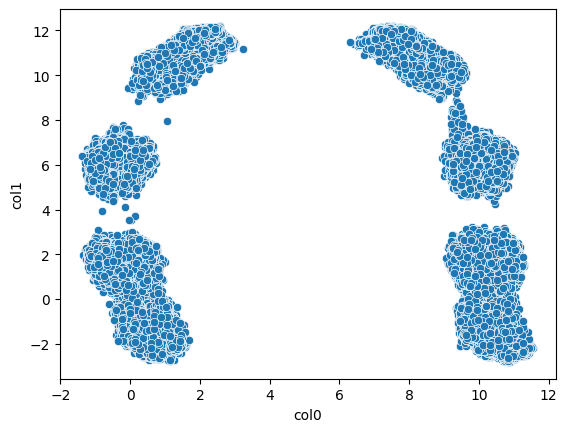

In [13]:
embedding_o = pd.DataFrame(embedding_o)
embedding_o.columns = ['col0','col1']

sns.scatterplot(embedding_o, x='col0', y='col1')

In [14]:
import numpy as np
# def visual_cluster(df, col0, col1):
#     if df[col0] < 4:
#         if df[col1] < 3.8:
#             return 0
#         if (df[col1] >= 3.8)&(df[col1])<8.5: 
#             return 1
#         if df[col1] >= 8.5:
#             return 2
#     if df[col0] >=4:
#         if df[col1] < 3.8:
#             return 3
#         if (df[col1] >= 3.8)&(df[col1])<8.5: 
#             return 4
#         if df[col1] >= 8.5:
#             return 5

# visual_cluster(embedding_o, 'col0', 'col1')    

def visual_cluster(df, col0, col1):
    col0_vals = df[col0]
    col1_vals = df[col1]

    # Initialize all labels to -1
    labels = np.full(len(df), -1)

    # Bounding boxes based on observed scatter plot (adjust if needed)
    labels[(col0_vals < 2) & (col1_vals < 3)] = 0
    labels[(col0_vals < 2) & (col1_vals >= 3) & (col1_vals < 8)] = 1
    labels[(col0_vals < 3) & (col1_vals >= 8)] = 2
    labels[(col0_vals > 8) & (col1_vals < 3.2)] = 3
    labels[(col0_vals > 8) & (col1_vals >= 3.2) & (col1_vals < 8)] = 4
    labels[(col0_vals > 6) & (col1_vals >= 8)] = 5

    return labels

embedding_o['cluster'] = visual_cluster(embedding_o, 'col0', 'col1')
#X_train['cluster'] = visual_cluster(embedding_o, 'col0', 'col1')

<Axes: xlabel='col0', ylabel='col1'>

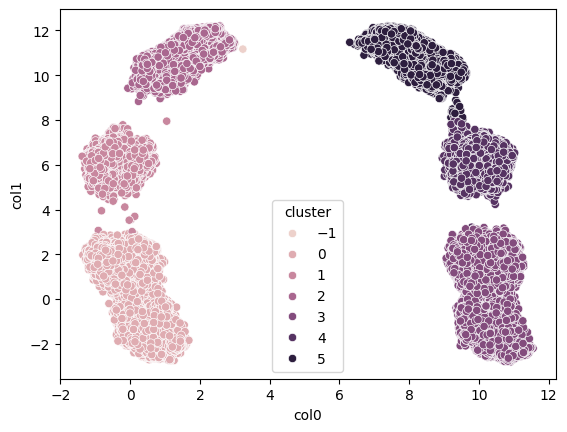

In [16]:
sns.scatterplot(embedding_o, x='col0', y='col1', hue='cluster')

In [106]:
len(updated_components)

22

In [286]:
def random_sample_o_column_proportions(df, col):
    return df[col].sample(500000,replace=True,).reset_index(drop='True')

o_col_list = updated_components#component_list_core+single_lists+component_list_two#component_list+single_lists+component_list_two #component_list+single_lists_one
random_dataframe_from_col_space = pd.DataFrame()
for i, col in enumerate(o_col_list):
    random_dataframe_from_col_space = pd.concat([random_dataframe_from_col_space,
               random_sample_o_column_proportions(X_train, col)], axis=1)
    
random_dataframe_from_col_space = random_dataframe_from_col_space[X_train.columns.tolist()]
    
expanded_random = pd.get_dummies(random_dataframe_from_col_space)

X_train_aug = X_train.copy()
X_train_aug['cluster'] = embedding_o['cluster']

# X_train_o_fake_sample = reducer_o.transform(expanded_random.astype('float').fillna(0))
# X_train_o_fake_sample = pd.DataFrame(X_train_o_fake_sample)

In [287]:
from sklearn.metrics import pairwise_distances

bottom_degrees_store = pd.DataFrame()
for i in tqdm(range(200)):
    sample_df = X_train_aug.select_dtypes(exclude='object').fillna(0).drop('cluster', axis=1)
    fake_sample_df = random_dataframe_from_col_space.select_dtypes(exclude='object').fillna(0).sample(1000)

    top_nodes = sample_df.index.tolist()
    bottom_nodes = fake_sample_df.index.tolist()

    dist_matrix = pd.DataFrame(pairwise_distances(sample_df, fake_sample_df, metric='cosine'))
    dist_matrix.index = top_nodes
    dist_matrix.columns = bottom_nodes

    row_inds, col_inds = np.triu_indices_from(dist_matrix.values, k=1)

# Create a DataFrame with row_i, row_j, value   
    upper_tri_df = pd.DataFrame({
    'row_i': dist_matrix.index[row_inds],
    'row_j': dist_matrix.columns[col_inds],
    'distance': dist_matrix.values[row_inds, col_inds]
    })


    edges = upper_tri_df[(upper_tri_df.distance > 0.5)&(upper_tri_df.distance <0.9)]

    edges = list(map(tuple, edges[['row_i','row_j']].values))



    B = nx.Graph()
    B.add_nodes_from(top_nodes, bipartite=0)
    B.add_nodes_from(bottom_nodes, bipartite=1)
    B.add_edges_from(edges)

    components = nx.connected_components(B)

# # Let's extract top-side nodes (bipartite=0) from each component
# bottom_nodes_in_components = []
# for comp in components:
#     bottom_nodes_in_components.append({n for n in comp if B.nodes[n]['bipartite'] == 1})

# bottom_nodes = [list(x) for x in bottom_nodes_in_components if len(x) > 1]
# flat_list_bottom = [item for sublist in bottom_nodes for item in sublist]
# # pos = nx.bipartite_layout(B, top_nodes)
# # nx.draw(B, pos, with_labels=True, node_color=["lightblue" if n in top_nodes else "lightgreen" for n in B.nodes()])
# # plt.title("Bipartite Graph")
# # plt.show()

    bottom_nodes = {n for n, d in B.nodes(data=True) if d.get('bipartite') == 1}

    # Get degrees of bottom nodes
    bottom_degrees = {node: [B.degree(node)] for node in bottom_nodes}

    bottom_degrees = pd.DataFrame().from_dict(bottom_degrees).transpose()
    bottom_degrees.columns = ['degree']

    bottom_degrees_store = pd.concat([bottom_degrees_store, bottom_degrees[bottom_degrees.degree >= 10]], axis=0)

  0%|          | 0/200 [00:00<?, ?it/s]

In [288]:
X_test_fake = random_dataframe_from_col_space.reset_index()[
    random_dataframe_from_col_space.reset_index()['index'].isin(bottom_degrees_store.reset_index().drop_duplicates('index')['index'])
].drop('index', axis=1)

In [289]:
X_test_fake.shape[0]

146330

In [291]:
embedding_o_fake = pd.DataFrame(reducer_o.transform(
    pd.get_dummies(X_test_fake.select_dtypes(include='object')).fillna(0)
))
embedding_o_fake.columns = ['col0','col1']

X_test_fake['cluster'] = visual_cluster(embedding_o_fake, 'col0', 'col1')

/home/fnnsll/Hive/Honey/synthetic/.venv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



<Axes: xlabel='col0', ylabel='col1'>

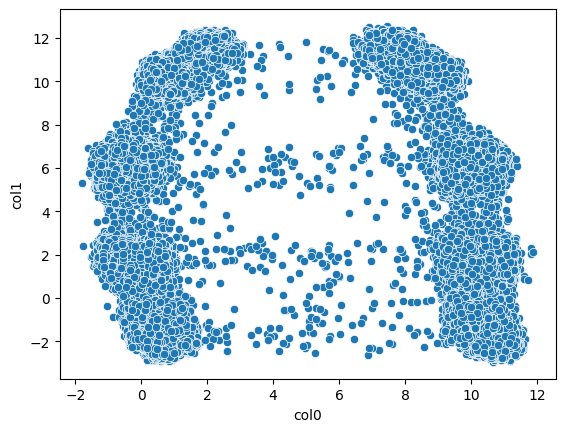

In [233]:
sns.scatterplot(embedding_o_fake, x='col0', y='col1')

In [292]:
embedding_o_fake_small = embedding_o_fake[
    embedding_o_fake.reset_index()['index'].isin(X_test_fake.reset_index()['index'])
]

In [293]:
embedding_o_fake_small['cluster'] = visual_cluster(embedding_o_fake_small, 'col0', 'col1')

/tmp/ipykernel_192633/564968849.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [236]:
embedding_o['cluster'].value_counts(normalize=True)

cluster
 3    0.254437
 0    0.239700
 5    0.138588
 2    0.130125
 4    0.122713
 1    0.114413
-1    0.000025
Name: proportion, dtype: float64

In [237]:
embedding_o_fake_small['cluster'].value_counts(normalize=True)

cluster
 3    0.245227
 0    0.234353
 5    0.148775
 2    0.135295
 4    0.122449
 1    0.111834
-1    0.002067
Name: proportion, dtype: float64

<Axes: xlabel='col0', ylabel='col1'>

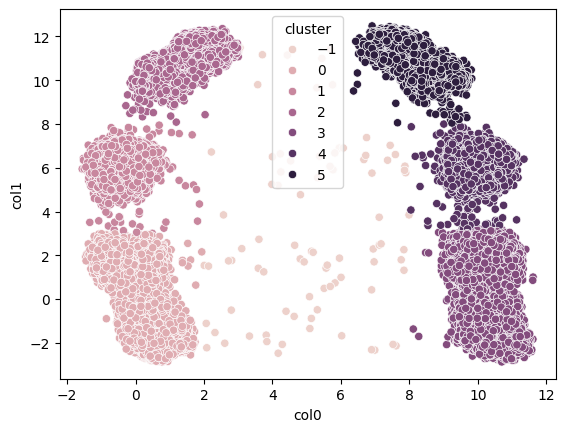

In [238]:
sns.scatterplot(embedding_o_fake_small, x='col0', y='col1', hue='cluster')

In [294]:
X_test_fake_smaller = X_test_fake.reset_index()[
    ~X_test_fake.reset_index()['index'].isin(
        embedding_o_fake_small[embedding_o_fake_small['cluster']==-1].reset_index()['index'])].drop('index',axis =1)

In [295]:
X_test_fake_smaller.shape[0]

146200

In [ ]:
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix

# 1. Load your data
# df = pd.read_csv("your_data.csv")
X_z = X_train_aug.drop(columns='cluster').select_dtypes(exclude='object').values   # 80 numeric features
y = X_train_aug['cluster'].values                 # integers 0..5

# 2. Scale features
scaler = StandardScaler()
Z_scaled = scaler.fit_transform(X_z)

# 3. Train/test split (stratified by y)
Z_train, Z_test, y_train, y_test = train_test_split(
    Z_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Build model
model = Sequential([
    Dense(128, activation='relu', input_shape=(60,)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(6, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 5. Train
history = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=50,
    batch_size=32,
    verbose=1
)

# 6. Evaluate on test set
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy: {test_acc:.4f}, Test loss: {test_loss:.4f}")

# 7. Detailed classification report
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
print(classification_report(y_test, y_pred, digits=4))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))

In [ ]:
from mostlyai import qa
qa.init_logging()

report_path, metrics = qa.report(syn_tgt_data=X_test_fake_smaller.drop('cluster', axis=1).sample(100000),
                                 trn_tgt_data=X_train,
                                 hol_tgt_data=X_test
                                 )

print(metrics.model_dump_json(indent=4))

[2025-06-02 18:41:34,062] INFO   : prepared training data for accuracy: (80000, 80)
[2025-06-02 18:41:34,266] INFO   : prepared holdout data for accuracy: (20000, 80)
[2025-06-02 18:41:35,152] INFO   : prepared synthetic data for accuracy: (100000, 80)
[2025-06-02 18:41:35,316] INFO   : encode datasets for embeddings
[2025-06-02 18:41:40,406] INFO   : calculated embeddings: syn=(20000, 107), trn=(20000, 107), hol=(20000, 107)
[2025-06-02 18:41:40,407] INFO   : report accuracy and correlations
[2025-06-02 18:41:40,407] INFO   : calculate original data bins
[2025-06-02 18:41:41,165] INFO   : store original data bins
[2025-06-02 18:41:41,354] INFO   : calculate synthetic data bins
[2025-06-02 18:41:41,871] INFO   : calculate correlations
[2025-06-02 18:41:49,515] INFO   : calculate correlations
[2025-06-02 18:41:57,004] INFO   : calculated univariates for 80 columns in 1.31 seconds
[2025-06-02 18:42:05,941] INFO   : calculated bivariate accuracies for 6320 combinations in 8.94 seconds


In [290]:
X_test_fake_smaller.to_csv('submission_5.csv')